# Licence Plate Detection — YOLO Only
Detect licence plates in images from the `data-images` folder using **YOLOv11** (`morsetechlab/yolov11-license-plate-detection`).
No OCR — purely bounding-box object detection.

## 1. Import Libraries

In [34]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from ultralytics import YOLO

print("Libraries imported.")

Libraries imported.


## 2. Settings

In [38]:
IMAGE_FOLDER    = Path("data-images")
CONF_THRESHOLD  = 0.30
YOLO_MODEL_NAME = "license-plate-finetune-v1n.onnx"
SUPPORTED_EXT   = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print(f"Folder : {IMAGE_FOLDER.resolve()}")
print(f"Model  : {YOLO_MODEL_NAME}")
print(f"Conf   : {CONF_THRESHOLD}")

Folder : C:\Users\krist\Documents\GitHub\Object-Detection-Research\data-images
Model  : license-plate-finetune-v1n.onnx
Conf   : 0.3


## 3. Load the YOLO Model
The model weights are downloaded automatically from Hugging Face on the first run.

In [39]:
model = YOLO(YOLO_MODEL_NAME)
print("Model loaded:", YOLO_MODEL_NAME)

WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Model loaded: license-plate-finetune-v1n.onnx


## 4. Discover Images

In [40]:
if not IMAGE_FOLDER.is_dir():
    raise FileNotFoundError(f"Folder not found: {IMAGE_FOLDER.resolve()}")

image_files = sorted(
    p for p in IMAGE_FOLDER.iterdir()
    if p.suffix.lower() in SUPPORTED_EXT
)

print(f"Found {len(image_files)} image(s):")
for p in image_files:
    print(f"  • {p.name}")

Found 3 image(s):
  • dsc0226.jpg
  • DSC_1939.JPG
  • nederland150.jpg


## 5. Run YOLO Detection
Run inference on every image and collect bounding boxes with confidence scores.

In [41]:
all_results = []

for img_path in image_files:
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print(f"  [skip] Could not read {img_path.name}")
        continue

    yolo_out = model(img_bgr, conf=CONF_THRESHOLD, verbose=False)[0]

    boxes = []
    for box in yolo_out.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        conf = round(float(box.conf[0]), 4)
        boxes.append({"x1": x1, "y1": y1, "x2": x2, "y2": y2, "conf": conf})

    all_results.append({
        "file":    img_path.name,
        "img_bgr": img_bgr,
        "boxes":   boxes,
    })
    print(f"  ✓ {img_path.name}  →  {len(boxes)} detection(s)")

print(f"\nDone. Processed {len(all_results)} image(s).")

Loading license-plate-finetune-v1n.onnx for ONNX Runtime inference...
requirements: Ultralytics requirements ['onnx', 'onnxruntime'] not found, attempting AutoUpdate...


   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ------ --------------------------------- 2.6/16.4 MB 15.7 MB/s eta 0:00:01
   --------------------- ------------------ 8.9/16.4 MB 23.3 MB/s eta 0:00:01
   ---------------------------------------- 16.4/16.4 MB 29.0 MB/s  0:00:00
   ---------------------------------------- 0.0/13.0 MB ? eta -:--:--
   ---------------------------- ----------- 9.4/13.0 MB 45.2 MB/s eta 0:00:01
   ---------------------------------------- 13.0/13.0 MB 45.3 MB/s  0:00:00

   ---------------------------------------- 0/4 [flatbuffers]
   ---------- ----------------------------- 1/4 [onnxruntime]
   ---------- ----------------------------- 1/4 [onnxruntime]
   ---------- ----------------------------- 1/4 [onnxruntime]
   ---------- ----------------------------- 1/4 [onnxruntime]
   ---------- ----------------------------- 1/4 [onnxruntime]
   ---------- ----------------------------- 1/4 [onnxruntime]
   ---------- -------------------------

## 6. Visualise Detections
Draw bounding boxes on each image and display it inline. Each box is labelled with its confidence score.

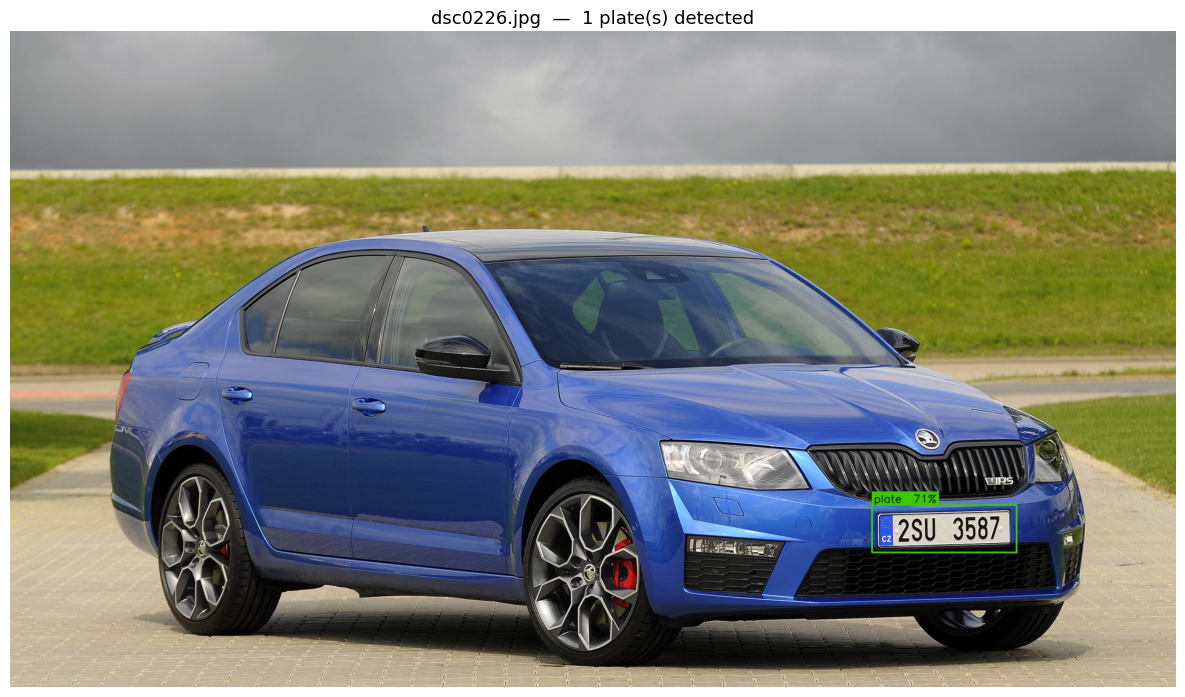

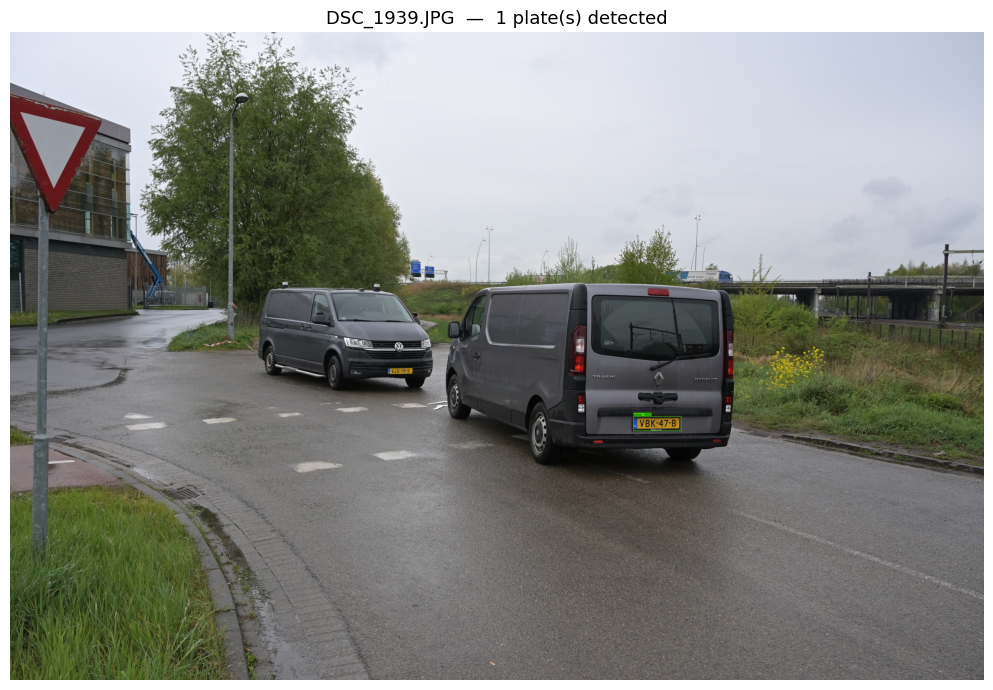

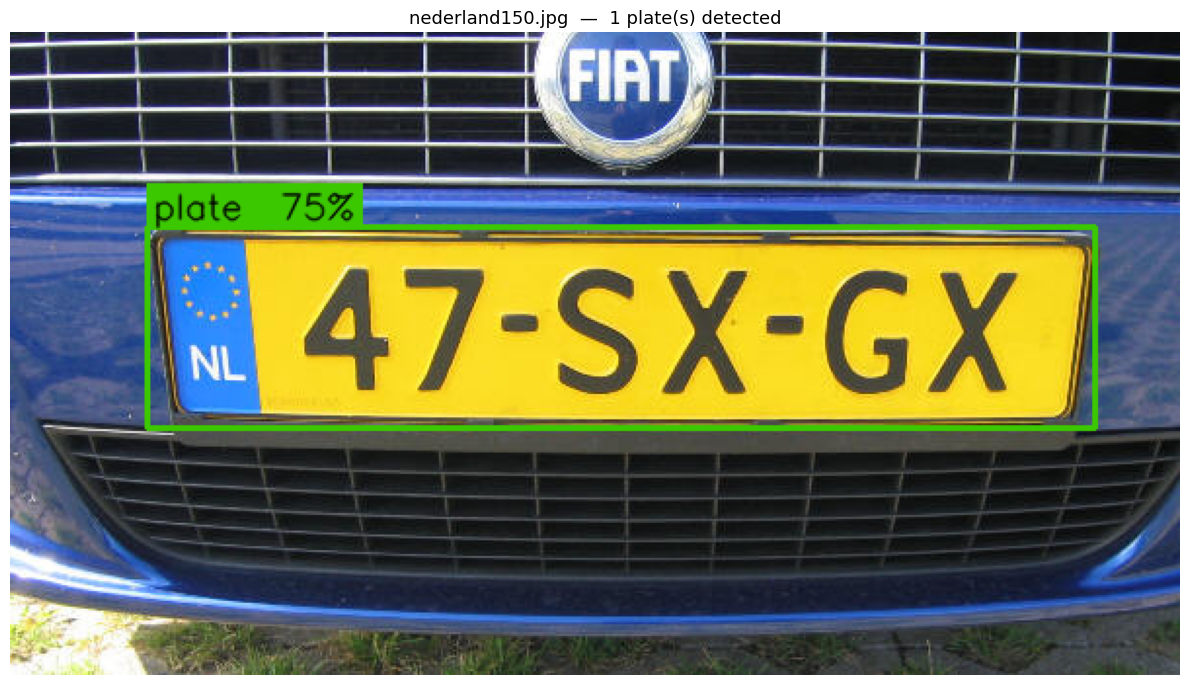

In [42]:
BOX_COLOR  = (0, 200, 60)   # BGR green
LABEL_COLOR = (0, 0, 0)     # black text

for result in all_results:
    img     = result["img_bgr"].copy()
    boxes   = result["boxes"]
    h, w    = img.shape[:2]

    for b in boxes:
        x1, y1, x2, y2, conf = b["x1"], b["y1"], b["x2"], b["y2"], b["conf"]
        label = f"plate  {conf:.0%}"

        # Bounding box
        cv2.rectangle(img, (x1, y1), (x2, y2), BOX_COLOR, 2)

        # Label background + text
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(img, (x1, y1 - th - 8), (x1 + tw + 6, y1), BOX_COLOR, -1)
        cv2.putText(img, label, (x1 + 3, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, LABEL_COLOR, 1, cv2.LINE_AA)

    # Display
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{result['file']}  —  {len(boxes)} plate(s) detected", fontsize=13)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## 7. Show Plate Crops
Display each detected region as a cropped close-up.

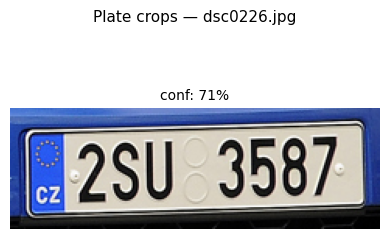

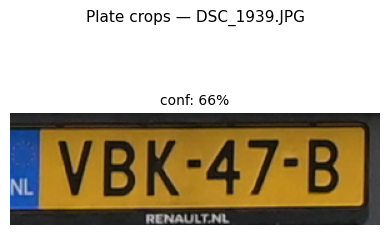

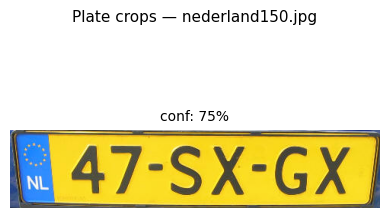

In [43]:
for result in all_results:
    boxes = result["boxes"]
    if not boxes:
        print(f"No detections in {result['file']}")
        continue

    img = result["img_bgr"]
    n   = len(boxes)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3))
    if n == 1:
        axes = [axes]

    for ax, b in zip(axes, boxes):
        crop = img[b["y1"]:b["y2"], b["x1"]:b["x2"]]
        ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        ax.set_title(f"conf: {b['conf']:.0%}", fontsize=10)
        ax.axis("off")

    plt.suptitle(f"Plate crops — {result['file']}", fontsize=11)
    plt.tight_layout()
    plt.show()